
Tolerance: 0.001
Gauss-Seidel iterations: 4
Jacobi iterations: 4


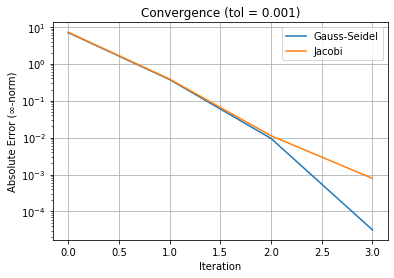


Tolerance: 1e-06
Gauss-Seidel iterations: 5
Jacobi iterations: 7


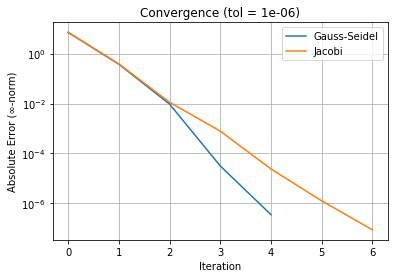


Tolerance: 1e-09
Gauss-Seidel iterations: 7
Jacobi iterations: 9


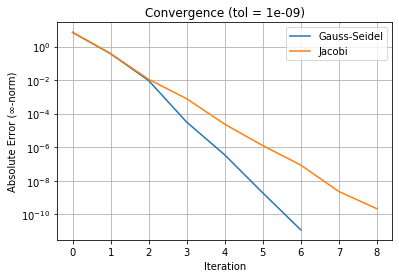

In [3]:
import numpy as np
import time
import matplotlib.pyplot as plt
def gauss_seidel(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    errors = []
    for k in range(max_iterations):
        x_new = x.copy()
        for i in range(n):
            s1 = sum(A[i][j] * x_new[j] for j in range(i))
            s2 = sum(A[i][j] * x[j] for j in range(i + 1, n))
            x_new[i] = (b[i] - s1 - s2) / A[i][i]
        error = np.linalg.norm(x_new - x, ord=np.inf)
        errors.append(error)
        if error < tol:
            return x_new, k + 1, errors
        x = x_new
    return x, max_iterations, errors
def jacobi(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    errors = []
    for k in range(max_iterations):
        x_new = np.zeros_like(x)
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]
        error = np.linalg.norm(x_new - x, ord=np.inf)
        errors.append(error)
        if error < tol:
            return x_new, k + 1, errors
        x = x_new
    return x, max_iterations, errors
A = np.array([[3, -0.1, -0.2],
              [0.1, 7, -0.3],
              [0.3, -0.2, 10]], dtype=float)
b = np.array([7.85, -19.3, 71.4], dtype=float)
x0 = np.zeros_like(b)
tolerances = [1e-3, 1e-6, 1e-9]
max_iterations = 100
for tol in tolerances:
    print(f"\nTolerance: {tol}")
    gs_sol, gs_iter, gs_errors = gauss_seidel(A, b, x0, tol, max_iterations)
    print("Gauss-Seidel iterations:", gs_iter)
    jac_sol, jac_iter, jac_errors = jacobi(A, b, x0, tol, max_iterations)
    print("Jacobi iterations:", jac_iter)
    plt.figure()
    plt.semilogy(gs_errors, label="Gauss-Seidel")
    plt.semilogy(jac_errors, label="Jacobi")
    plt.xlabel("Iteration")
    plt.ylabel("Absolute Error (∞-norm)")
    plt.title(f"Convergence (tol = {tol})")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
#As tolerance decreases, the number of iterations increases
#Gauss-Seidel always converges faster
#Used ChatGPT to help with graphs and grouping iterations with its tolerance value